In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import sys

ROOT = Path().resolve().parent
sys.path.append(str(ROOT))

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid')

plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
from importlib import reload
import src.preprocessing as preprocessing
from src.preprocessing import summarize_dataset, daily_timestamp_quality

In [3]:
p1g =pd.read_csv('../data/raw/Planta1_Generacion.csv')
p2g = pd.read_csv('../data/raw/Planta2_Generacion.csv')
p1s = pd.read_csv('../data/raw/Planta1_Sensores.csv')
p2s = pd.read_csv('../data/raw/Planta2_Sensores.csv')

In [236]:
# convertir 'fecha_hora' a datetime con dayfirst=True
p1g['fecha_hora'] = pd.to_datetime(p1g['fecha_hora'].astype(str).str.strip(), errors='coerce')
p2g['fecha_hora'] = pd.to_datetime(p2g['fecha_hora'].astype(str).str.strip(), errors='coerce')
p1s['fecha_hora'] = pd.to_datetime(p1s['fecha_hora'].astype(str).str.strip(), errors='coerce')
p2s['fecha_hora'] = pd.to_datetime(p2s['fecha_hora'].astype(str).str.strip(), errors='coerce')

# fijar id_planta = 'p1' para todos los registros
p1g['id_planta'] = 'p1'
p2g['id_planta'] = 'p2'
p1s['id_planta'] = 'p1'
p2s['id_planta'] = 'p2'

In [237]:
#Análisis de regularidad de series temporales para detección de anomalías 
from src.preprocessing import summarize_dataset

datasets = {
    'DC/AC Power - Energy - Plant 1': p1g,
    'DC/AC Power - Energy - Plant 2': p2g,
    'Irradiation - Temperature - Plant 1': p1s,
    'Irradiation - Temperature - Plant 2': p2s,
}

summary = [summarize_dataset(df, name) for name, df in datasets.items()]
summary_df = pd.DataFrame(summary)
summary_df

,dataset,rows,unique_timestamps,start,end,constant_interval,min_step,max_step,expected_step_15min,interval_counts,parse_failures
0,DC/AC Power - Energy - Plant 1,68778,3158,2020-05-15,2020-06-17 23:45:00,False,0 days 00:15:00,0 days 09:00:00,0 days 00:15:00,"{0 days 00:15:00: 3148, 0 days 00:30:00: 2, 0 ...",0
1,DC/AC Power - Energy - Plant 2,67698,3259,2020-05-15,2020-06-17 23:45:00,False,0 days 00:15:00,0 days 00:30:00,0 days 00:15:00,"{0 days 00:15:00: 3253, 0 days 00:30:00: 5}",0
2,Irradiation - Temperature - Plant 1,3182,3182,2020-05-15,2020-06-17 23:45:00,False,0 days 00:15:00,0 days 07:15:00,0 days 00:15:00,"{0 days 00:15:00: 3173, 0 days 00:30:00: 2, 0 ...",0
3,Irradiation - Temperature - Plant 2,3259,3259,2020-05-15,2020-06-17 23:45:00,False,0 days 00:15:00,0 days 00:30:00,0 days 00:15:00,"{0 days 00:15:00: 3253, 0 days 00:30:00: 5}",0


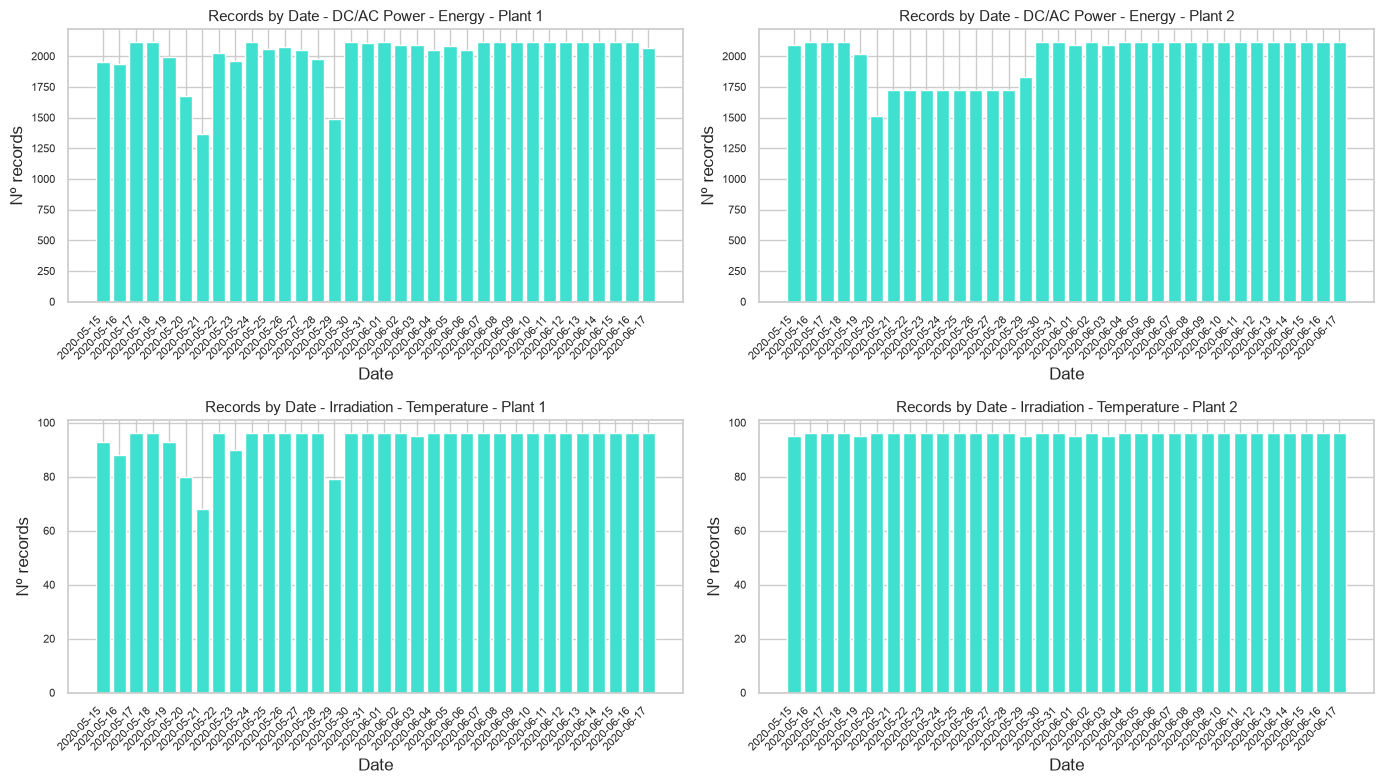

In [238]:
#Visualización de gaps temporales en los 4 datasets
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=False)
axes = axes.flatten()

for ax, (name, df) in zip(axes, datasets.items()):
    df = df.copy()
    df["fecha"] = df["fecha_hora"].dt.date

    daily_counts = df.groupby("fecha").size()

    x = np.arange(len(daily_counts))

    ax.bar(x, daily_counts.values, color="turquoise")

    ax.set_xticks(x)
    ax.set_xticklabels(daily_counts.index.astype(str), rotation=45, ha="right", fontsize=8)

    ax.set_title(f"Records by Date - {name}", fontsize=11)
    ax.set_xlabel("Date")
    ax.set_ylabel("Nº records")
    ax.tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()


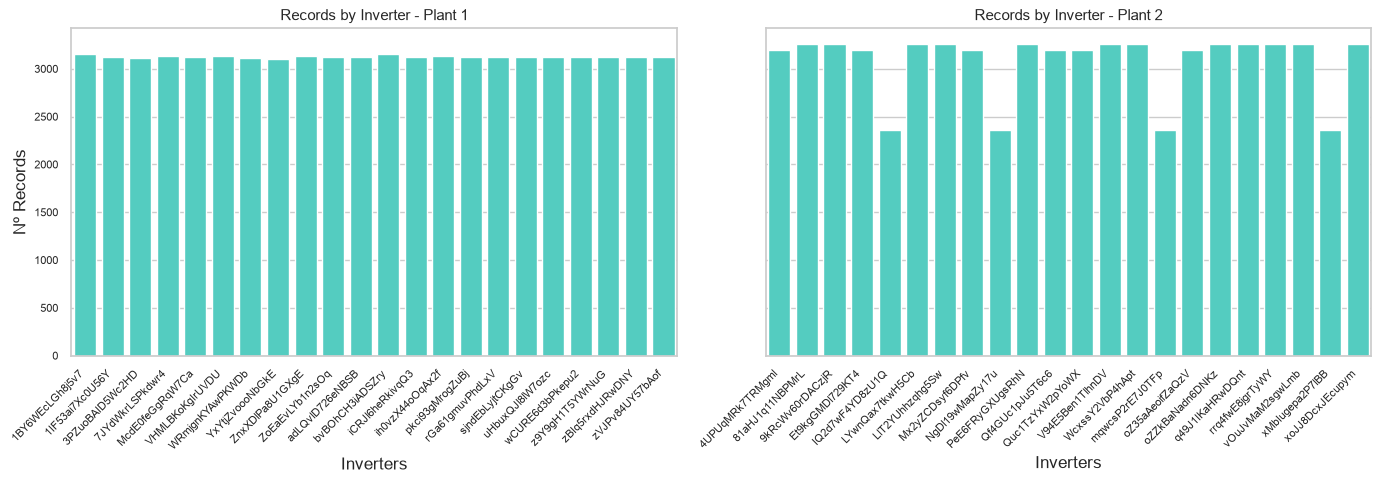

In [239]:
#Visualización de registros por inverter

datasets = {
    "Plant 1": p1g,
    "Plant 2": p2g,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (name, df) in zip(axes, datasets.items()):
    inverter_counts = df.groupby("id_inversor").size()

    sns.barplot(
        x=inverter_counts.index,
        y=inverter_counts.values,
        ax=ax,
        color="turquoise"
    )

    ax.set_title(f"Records by Inverter - {name}", fontsize=11)
    ax.set_xlabel("Inverters")
    ax.set_ylabel("Nº Records")

    ax.set_xticks(range(len(inverter_counts)))
    ax.set_xticklabels(inverter_counts.index.astype(str), rotation=45, ha="right")

    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()

In [240]:
#crear datasets combinados de generacion y sensores por separado
df_generacion = pd.concat([p1g, p2g], axis='index')
df_atmosferico = pd.concat([p1s, p2s], axis='index')

In [254]:
#Datasets temporales de conteo de registros
from src.preprocessing import daily_timestamp_quality

conteo_registros_atmosferico = daily_timestamp_quality(
    df_atmosferico,
    group_cols=["id_planta"])

conteo_registros_generacion = daily_timestamp_quality(
    df_generacion,
    group_cols=["id_planta", "id_inversor"])

In [256]:
conteo_registros_atmosferico.head(1)

,id_planta,fecha,registros_observados,primer_timestamp,ultimo_timestamp,registros_esperados,missing_timestamps,pct_missing
0,p1,2020-05-15,93,2020-05-15,2020-05-15 23:00:00,96,3,0.03125


### Validacion de los datasets (conclusiones)
1. El valor de los registros de DC en la planta 1 está a una escala 10 veces superior de lo que deberia, comparando con el resto de datos de la planta 2. Es muy probale que los errores sean de medicion y simplemente sea un problema de unidades al recoger los datos.
2. Tenemos irregularidades en los intervalos de las series temporales tanto para los datasets de generacion como de sensores: Faltan registros de intervalos de 15 minutos. Algunos inverters de la planta 2 muestran ausencia notable de registros (en concreto 4 de ellos). Continuar profundizando en este análisis en la fase de EDA.
3. La variable `irradiacion_wh_m2` de los datasets `Planta1_Sensores.csv` y `Planta1_Sensores.csv` muestra valores que no se ajustan a la irradiación solar habitual, expresada en KWh/m² (en vez de Wh/m²).

### Acciones tomadas
1. Tras consultar a Agente IA especializado. se ha tomado la decisión de mover la coma una posición en los datos de potencia DC de la planta 1 ya que después de analizar los datos de Irradiación, Temperatura y Generación, todo lleva a indicar que el problema es debido a un error de medición técnico de los sensores de la planta 1. En un caso real se consultaría esta decisión con un técnico real especializado si fuera posible, pero para éste caso concreto se ha consultado a un Agente IA especializado.
2. Los intervalos temporales no han sido modificados para mantener la integradidad de los datos originales de cara a hacer análisis posteriores.
3. Unidades y nombre de la variable `irradiacion_wh_m2` no se modificarán. Dado que no se dispone de documentación sobre las unidades del sensor, la variable se mantendrá sin cambios y se considerará un indicador relativo de irradiación a lo largo de todo el análisis. Por consiguiente, los análisis de irradiación se centrarán en la coherencia temporal y en la detección de anomalías, más que en los valores físicos absolutos.

In [242]:
#Movemos la coma una posicion hacia la izquierda para que los valores sean correctos
mask = df_generacion["id_planta"] == "p1"
df_generacion.loc[mask, "potencia_dc_kw"] /= 10

In [245]:
#creamos objetos parquet
df_atmosferico.to_parquet('../data/intermediate/tablon_analitico_importacion_atmosferico.parquet')
df_generacion.to_parquet('../data/intermediate/tablon_analitico_importacion_generacion.parquet')
conteo_registros_atmosferico.to_parquet('../data/intermediate/tablon_analitico_conteo_atmosferico.parquet')
conteo_registros_generacion.to_parquet('../data/intermediate/tablon_analitico_conteo_generacion.parquet')